# Practica final NLP - Ejercicio 4
## Metricas y conclusiones

Cogemos el mejor modelo (Logistic Regression con BoW) y mostramos las
metricas finales: classification report y matriz de confusion.

## Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

## 1. Cargar datos y reentrenar el mejor modelo

In [2]:
df = pd.read_csv('reviews_preprocessed.csv').dropna(subset=['clean_text'])

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000, min_df=2)
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_bow, y_train)
pred = modelo.predict(X_test_bow)

## 2. Metricas globales

In [3]:
print('Accuracy: ', accuracy_score(y_test, pred))
print('Precision:', precision_score(y_test, pred))
print('Recall:   ', recall_score(y_test, pred))
print('F1:       ', f1_score(y_test, pred))

Accuracy:  0.8704352176088044
Precision: 0.8648915187376726
Recall:    0.8778778778778779
F1:        0.8713363139592648


## 3. Classification report

In [4]:
print(classification_report(y_test, pred, target_names=['Negativa', 'Positiva']))

              precision    recall  f1-score   support

    Negativa       0.88      0.86      0.87      1000
    Positiva       0.86      0.88      0.87       999

    accuracy                           0.87      1999
   macro avg       0.87      0.87      0.87      1999
weighted avg       0.87      0.87      0.87      1999



## 4. Matriz de confusion

[[863 137]
 [122 877]]


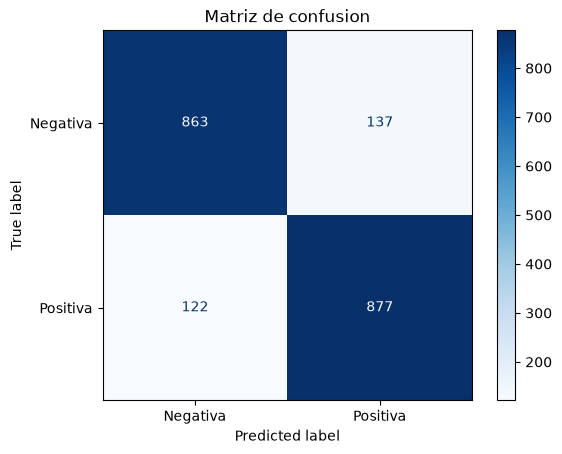

In [5]:
cm = confusion_matrix(y_test, pred)
print(cm)

disp = ConfusionMatrixDisplay(cm, display_labels=['Negativa', 'Positiva'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusion')
plt.show()

## Conclusiones

- El mejor modelo es **Logistic Regression** con Bag of Words.
- Las metricas son buenas (~87% de F1) y bastante equilibradas entre las
  dos clases.
- La matriz de confusion muestra que el modelo se equivoca de forma
  parecida en positivas y negativas.
